# Choosing models

## Importing libraries

In [ ]:
%%capture
!pip install Levenshtein apted

In [ ]:
import abc
import typing
import pathlib
import json
import zipfile

import gdown
import tqdm
import IPython.display
import torch
import torchvision.transforms
import PIL.Image
import pandas as pd
import numpy as np

## Uploading data

In [ ]:
ids_cache_files: list[str] = [
    '1j2cLQgg-IujUP9JeIndI35bN7yW1zdRR',
    '1jaPkLb125G8kQkwtXjvBHgOswoN_3SPP',
    '183F3lKWUi4ms9kZPF42INbrysi-4g6iI',
    '1d3zeHDoQ0CV_wtoWWJ2jMBv35x0TC9ZP',
]

In [ ]:
for file_id in ids_cache_files:
  url = f'https://drive.google.com/uc?id={file_id}'
  gdown.download(url)

Downloading...
From: https://drive.google.com/uc?id=1j2cLQgg-IujUP9JeIndI35bN7yW1zdRR
To: /content/Cache (PaddleRecognizer).json
100%|██████████| 1.75M/1.75M [00:00<00:00, 160MB/s]
Downloading...
From: https://drive.google.com/uc?id=1jaPkLb125G8kQkwtXjvBHgOswoN_3SPP
To: /content/Cache (Qwen3VLRecognizer).json
100%|██████████| 5.23M/5.23M [00:00<00:00, 185MB/s]
Downloading...
From: https://drive.google.com/uc?id=183F3lKWUi4ms9kZPF42INbrysi-4g6iI
To: /content/Cache (RotationPaddleRecognizer).json
100%|██████████| 1.78M/1.78M [00:00<00:00, 94.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=1d3zeHDoQ0CV_wtoWWJ2jMBv35x0TC9ZP
To: /content/Cache (RotationQwen3VLRecognizer).json
100%|██████████| 5.01M/5.01M [00:00<00:00, 88.5MB/s]


In [ ]:
file_id = '1DHkAtibtxL1irh8FZ-8J2FII6veDFQLI'
url = f'https://drive.google.com/uc?id={file_id}'
path_to_model_weights = 'model_weights.pth'
gdown.download(url, path_to_model_weights)

Downloading...
From: https://drive.google.com/uc?id=1DHkAtibtxL1irh8FZ-8J2FII6veDFQLI
To: /content/model_weights.pth
100%|██████████| 16.9k/16.9k [00:00<00:00, 35.4MB/s]


'model_weights.pth'

In [ ]:
file_id = '1wLkkvbfTHKm4dZbX4HzompRLdo7bPanp'
url = f'https://drive.google.com/uc?id={file_id}'
dataset_zip = pathlib.Path('dataset.zip')
gdown.download(url, dataset_zip.name)

zipfile.ZipFile(dataset_zip, 'r').extractall('.')
!rm '{dataset_zip}'

Downloading...
From (original): https://drive.google.com/uc?id=1wLkkvbfTHKm4dZbX4HzompRLdo7bPanp
From (redirected): https://drive.google.com/uc?id=1wLkkvbfTHKm4dZbX4HzompRLdo7bPanp&confirm=t&uuid=023e1bfe-e991-46a2-9232-ec152663c023
To: /content/dataset.zip
100%|██████████| 50.5M/50.5M [00:00<00:00, 161MB/s]


In [ ]:
path_to_data = pathlib.Path(dataset_zip.stem)

In [ ]:
class TestImage(typing.NamedTuple):
  name: str
  path_to_img: pathlib.Path
  html: str

In [ ]:
test_images: list[TestImage] = []
with open(path_to_data / 'synthetic_data.json') as file:
  name_to_html: dict[str, str] = json.load(file)

for path_to_image in path_to_data.rglob('*.png'):
  test_images.append(TestImage(
      name=path_to_image.name,
      path_to_img=path_to_image,
      html=name_to_html[path_to_image.name],
  ))

In [ ]:
test_images.sort(key=lambda img: img.name)

In [ ]:
IPython.display.display(IPython.display.HTML(test_images[0].html))

## Creating an evaluation function

In [ ]:
from collections import deque

import Levenshtein
from apted import APTED, Config
from apted.helpers import Tree
from lxml import etree, html


class TableTree(Tree):
    def __init__(self, tag, colspan=None, rowspan=None, content=None, *children):
        self.tag = tag
        self.colspan = colspan
        self.rowspan = rowspan
        self.content = content
        self.children = list(children)

    def bracket(self):
        """Show tree using brackets notation"""
        if self.tag == 'td':
            result = '"tag": %s, "colspan": %d, "rowspan": %d, "text": %s' % \
                     (self.tag, self.colspan, self.rowspan, self.content)
        else:
            result = '"tag": %s' % self.tag
        for child in self.children:
            result += child.bracket()
        return "{{{}}}".format(result)


class CustomConfig(Config):
    @staticmethod
    def maximum(*sequences):
        """Get maximum possible value
        """
        return max(map(len, sequences))

    def normalized_distance(self, *sequences):
        """Get distance from 0 to 1
        """
        return float(Levenshtein.distance(*sequences)) / self.maximum(*sequences)

    def rename(self, node1, node2):
        """Compares attributes of trees"""
        if (node1.tag != node2.tag) or (node1.colspan != node2.colspan) or (node1.rowspan != node2.rowspan):
            return 1.
        if node1.tag == 'td':
            if node1.content or node2.content:
                return self.normalized_distance(node1.content, node2.content)
        return 0.


class TEDS(object):
    ''' Tree Edit Distance basead Similarity
    '''
    def __init__(self, structure_only=False, n_jobs=1, ignore_nodes=None):
        assert isinstance(n_jobs, int) and (n_jobs >= 1), 'n_jobs must be an integer greather than 1'
        self.structure_only = structure_only
        self.n_jobs = n_jobs
        self.ignore_nodes = ignore_nodes
        self.__tokens__ = []

    def tokenize(self, node):
        ''' Tokenizes table cells
        '''
        self.__tokens__.append('<%s>' % node.tag)
        if node.text is not None:
            self.__tokens__ += list(node.text)
        for n in node.getchildren():
            self.tokenize(n)
        if node.tag != 'unk':
            self.__tokens__.append('</%s>' % node.tag)
        if node.tag != 'td' and node.tail is not None:
            self.__tokens__ += list(node.tail)

    def load_html_tree(self, node, parent=None):
        ''' Converts HTML tree to the format required by apted
        '''
        global __tokens__
        if node.tag == 'td':
            if self.structure_only:
                cell = []
            else:
                self.__tokens__ = []
                self.tokenize(node)
                cell = self.__tokens__[1:-1].copy()
            new_node = TableTree(node.tag,
                                 int(node.attrib.get('colspan', '1') or '1'),
                                 int(node.attrib.get('rowspan', '1') or '1'),
                                 cell, *deque())
        else:
            new_node = TableTree(node.tag, None, None, None, *deque())
        if parent is not None:
            parent.children.append(new_node)
        if node.tag != 'td':
            for n in node.getchildren():
                self.load_html_tree(n, new_node)
        if parent is None:
            return new_node

    def evaluate(self, pred, true):
        ''' Computes TEDS score between the prediction and the ground truth of a
            given sample
        '''
        if (not pred) or (not true):
            return 0.0
        parser = html.HTMLParser(remove_comments=True, encoding='utf-8')
        pred = html.fromstring(pred, parser=parser)
        true = html.fromstring(true, parser=parser)
        if pred.xpath('body/table') and true.xpath('body/table'):
            pred = pred.xpath('body/table')[0]
            true = true.xpath('body/table')[0]
            if self.ignore_nodes:
                etree.strip_tags(pred, *self.ignore_nodes)
                etree.strip_tags(true, *self.ignore_nodes)
            n_nodes_pred = len(pred.xpath(".//*"))
            n_nodes_true = len(true.xpath(".//*"))
            n_nodes = max(n_nodes_pred, n_nodes_true)
            tree_pred = self.load_html_tree(pred)
            tree_true = self.load_html_tree(true)
            distance = APTED(tree_pred, tree_true, CustomConfig()).compute_edit_distance()
            return 1.0 - (float(distance) / n_nodes)
        else:
            return 0.0

    def batch_evaluate(self, pred_json, true_json):
        ''' Computes TEDS score between the prediction and the ground truth of
            a batch of samples
            @params pred_json: {'FILENAME': 'HTML CODE', ...}
            @params true_json: {'FILENAME': 'HTML CODE', ...}
            @output: {'FILENAME': 'TEDS SCORE', ...}
        '''
        samples = true_json.keys()
        # if self.n_jobs == 1:
        scores = [
          self.evaluate(
              pred_json[filename],
              true_json[filename],
          ) for filename in tqdm.tqdm(samples)
        ]
        # else:
        #     inputs = [{'pred': pred_json.get(filename, ''), 'true': true_json[filename]['html']} for filename in samples]
        #     scores = parallel_process(inputs, self.evaluate, use_kwargs=True, n_jobs=self.n_jobs, front_num=1)
        scores = dict(zip(samples, scores))
        return scores


if __name__ == '__main__':
    import json
    import pprint


    teds = TEDS()
    scores = teds.batch_evaluate(
        dict(list(name_to_html.items())[:10]),
        dict(list(name_to_html.items())[:10]),
    )
    pp = pprint.PrettyPrinter()
    pp.pprint(scores)

100%|██████████| 10/10 [00:06<00:00,  1.62it/s]

{'image_000029_1634629328.565314.png': 1.0,
 'image_000044_1634629328.589694.png': 1.0,
 'image_000049_1634629328.598731.png': 1.0,
 'image_000053_1634629328.604574.png': 1.0,
 'image_000118_1634629347.784341.png': 1.0,
 'image_000130_1634629347.801666.png': 1.0,
 'image_000134_1634629347.808102.png': 1.0,
 'image_000150_1634629347.832551.png': 1.0,
 'image_000175_1634629347.873343.png': 1.0,
 'image_000184_1634629347.887891.png': 1.0}


In [ ]:
class Cache:
  def __init__(self, name: str) -> None:
    self.name = name
    path_to_cache = pathlib.Path(f'Cache ({self.name}).json')
    if path_to_cache.exists():
      with open(path_to_cache, 'r', encoding='UTF-8') as file:
        self.cache = json.load(file)
    else:
      self.cache = {}

  def update_cache(self, key: str, value: str) -> None:
    self.cache[key] = value
    with open(f'Cache ({self.name}).json', 'w', encoding='UTF-8') as file:
      json.dump(self.cache, file)

  def get(self, key: str) -> str | None:
    return self.cache.get(key)

In [ ]:
class TableRecognizer(abc.ABC):
  def __init__(self) -> None:
    self.cache = Cache(self.__class__.__name__)

  def cache_pred(self, path_to_img: pathlib.Path) -> str:
    path_to_img = str(path_to_img)
    value = self.cache.get(path_to_img)
    if value is not None:
      return value

    value = self.pred(path_to_img)
    self.cache.update_cache(path_to_img, value)

  @abc.abstractmethod
  def pred(self, path_to_img: pathlib.Path) -> str:
    pass

In [ ]:
def get_metrics(
  model: TableRecognizer,
) -> dict[typing.Literal['TEDS', 'TEDS-struct'], float]:
  pred_json: dict[str, str] = {image.name: model.cache_pred(image.path_to_img) for image in tqdm.tqdm(test_images)}
  true_json: dict[str, str] = {image.name: image.html for image in test_images}
  teds, teds_struct = TEDS(), TEDS(structure_only=True)
  teds_metric = sum(teds.batch_evaluate(pred_json, true_json).values()) / len(true_json)
  teds_struct_metric = sum(teds_struct.batch_evaluate(pred_json, true_json).values()) / len(true_json)
  return {'TEDS': teds_metric, 'TEDS-struct': teds_struct_metric}

In [ ]:
def format_html(html_table: str) -> str:
    html_code = """<html>
    <head>
    <meta charset="UTF-8">
    <style>
    table, th, td {
      border: 1px solid black;
      font-size: 10px;
    }
    </style>
    </head>
    <body>
    <table frame="hsides" rules="groups" width="100%%">
    %s
    </table>
    </body>
    </html>""" % html_table
    return html_code

## Declaring Models

## Evaluation of models (without modifications)

### PaddleRecognizer

In [ ]:
%%capture
!python -m pip install paddlepaddle-gpu==3.3.0 -i https://www.paddlepaddle.org.cn/packages/stable/cu130/
!python -m pip install "paddleocr[all]"

Sometimes it may be necessary to restart the session.

In [ ]:
from paddleocr import PaddleOCRVL

Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.


In [ ]:
%%capture
pipeline = PaddleOCRVL(
    device='gpu:0',
    precision='fp16',
)

Creating model: ('PP-DocLayoutV3', None)
Using official model (PP-DocLayoutV3), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-DocLayoutV3`.
Creating model: ('PaddleOCR-VL-1.5-0.9B', None)
Using official model (PaddleOCR-VL-1.5), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PaddleOCR-VL-1.5`.
Loading configuration file /root/.paddlex/official_models/PaddleOCR-VL-1.5/config.json
Loading weights file /root/.paddlex/official_models/PaddleOCR-VL-1.5/model.safetensors
use GQA - num_heads: 16- num_key_value_heads: 2
use GQA - num_heads: 16- num_key_value_heads: 2
use GQA - num_heads: 16- num_key_value_heads: 2
use GQA - num_heads: 16- num_key_value_heads: 2
use GQA - num_heads: 16- num_key_value_heads: 2
use GQA - num_heads: 16- num_key_value_heads: 2
use GQA - num_heads: 16- num_key_value_heads: 2
use GQA - num_heads: 16- num_key_value_heads: 2
use GQA - num_heads: 16- num_key_value_heads: 2
u

In [ ]:
class PaddleRecognizer(TableRecognizer):
  def pred(self, path_to_img: pathlib.Path) -> str:
    path_to_img = str(path_to_img)
    output = pipeline.predict(path_to_img)
    try:
      res = next(iter(output))
      html = format_html(res['parsing_res_list'][0].content)
    except Exception:
      html = ''

    return html

In [ ]:
path_to_img = test_images[1].path_to_img
html_img = PaddleRecognizer().cache_pred(path_to_img)

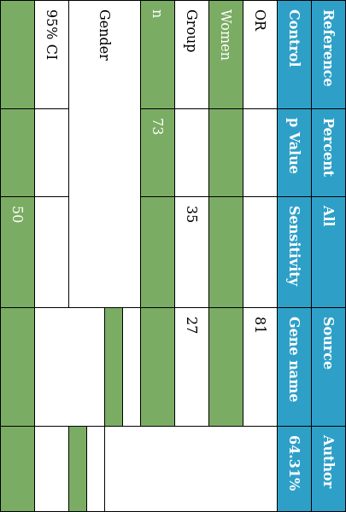

In [ ]:
IPython.display.display(IPython.display.Image(filename=path_to_img))

In [ ]:
IPython.display.display(IPython.display.HTML(html_img))

In [ ]:
res = get_metrics(PaddleRecognizer())
res


100%|██████████| 1000/1000 [00:00<00:00, 395987.92it/s]

100%|██████████| 1000/1000 [02:29<00:00,  6.68it/s]


{'TEDS': 0.6053332055050673, 'TEDS-struct': 0.6778228569186884}

In [ ]:
print(
    f'TEDS: {res['TEDS']:.3f}\n'
    f'TEDS-struct: {res['TEDS-struct']:.3f}'
)

TEDS: 0.605
TEDS-struct: 0.678


In [ ]:
all_result = {}
all_result['PaddleRecognizer'] = res

### Qwen3-VL-2B

In [ ]:
%%capture
!pip install git+https://github.com/huggingface/transformers

In [ ]:
torch.cuda.empty_cache()

In [ ]:
from transformers import Qwen3VLForConditionalGeneration, AutoProcessor


model = Qwen3VLForConditionalGeneration.from_pretrained(
    'Qwen/Qwen3-VL-2B-Instruct',
    torch_dtype=torch.float16,
    device_map='auto',
)
processor = AutoProcessor.from_pretrained("Qwen/Qwen3-VL-2B-Instruct")

In [ ]:
class Qwen3VLRecognizer(TableRecognizer):
    def pred(self, path_to_img: pathlib.Path) -> str:
        messages = [
            {
                "role": "user",
                "content": [
                    {
                        "type": "image",
                        "image": str(path_to_img),
                    },
                    {
                        "type": "text",
                        "text": (
                            "Extract the table from this image and output it as valid HTML. "
                            "Use <table>, <thead>, <tbody>, <tr>, <th>, <td> tags. "
                            "Include basic styling: border: 1px solid black; font-size: 10px;. "
                            "Preserve all cells, including rowspan and colspan if present."
                        )
                    },
                ],
            }
        ]

        inputs = processor.apply_chat_template(
            messages,
            tokenize=True,
            add_generation_prompt=True,
            return_dict=True,
            return_tensors="pt"
        )
        inputs = inputs.to(model.device)

        generated_ids = model.generate(**inputs, max_new_tokens=2048)
        generated_ids_trimmed = [
            out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
        ]
        output_text = processor.batch_decode(
            generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
        )
        return format_html(output_text[0].strip('```html').strip('```').strip())

In [ ]:
path_to_img = pathlib.Path('/content/dataset/images/image_000000_1634629104.262938.png')
html_img = Qwen3VLRecognizer().cache_pred(path_to_img)

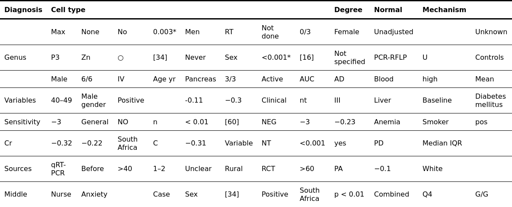

In [ ]:
IPython.display.display(IPython.display.Image(filename=path_to_img))

In [ ]:
IPython.display.display(IPython.display.HTML(html_img))

In [ ]:
res = get_metrics(Qwen3VLRecognizer())
res

100%|██████████| 1000/1000 [02:03<00:00,  8.08it/s]


{'TEDS': 0.12973023094947222, 'TEDS-struct': 0.2643434157941214}

In [ ]:
print(
    f'TEDS: {res['TEDS']:.3f}\n'
    f'TEDS-struct: {res['TEDS-struct']:.3f}'
)

TEDS: 0.130
TEDS-struct: 0.264


In [ ]:
all_result['Qwen3VLRecognizer'] = res

## Evaluation of models (with modifications)

### RotationPaddleRecognizer

In [ ]:
class RotationModel(torch.nn.Module):
  def __init__(self, number_rotation: int):
    super().__init__()
    self.number_rotation = number_rotation
    self.layers = torch.nn.Sequential(
        torch.nn.Conv2d(1, self.number_rotation, 7),
        torch.nn.ReLU(),
        torch.nn.BatchNorm2d(self.number_rotation),

        torch.nn.Conv2d(self.number_rotation, self.number_rotation, 3),
        torch.nn.ReLU(),
        torch.nn.BatchNorm2d(self.number_rotation),

        torch.nn.Conv2d(self.number_rotation, self.number_rotation, 3),
        torch.nn.ReLU(),
        torch.nn.BatchNorm2d(self.number_rotation),

        torch.nn.Conv2d(self.number_rotation, self.number_rotation, 3),
        torch.nn.ReLU(),
        torch.nn.BatchNorm2d(self.number_rotation),

        torch.nn.Conv2d(self.number_rotation, self.number_rotation, 3),
        torch.nn.ReLU(),
        torch.nn.BatchNorm2d(self.number_rotation),

        torch.nn.AdaptiveAvgPool2d(1),
        torch.nn.Flatten(),
        torch.nn.Linear(self.number_rotation, self.number_rotation),
        torch.nn.BatchNorm1d(self.number_rotation),
        torch.nn.Softmax(dim=1),
    )

  def forward(self, x: torch.FloatTensor) -> float:
    return self.layers(x)

In [ ]:
class RotationPaddleRecognizer(TableRecognizer):
  transform = torchvision.transforms.Compose([
      torchvision.transforms.Grayscale(num_output_channels=1),
      torchvision.transforms.Resize((256, 256)),
      torchvision.transforms.ToTensor(),
  ])

  def __init__(self) -> None:
    super().__init__()
    self.model = RotationModel(4)
    self.model.load_state_dict(
        torch.load(
            path_to_model_weights,
            weights_only=True,
        ),
    )
    self.model.eval()

  def pred(self, path_to_img: pathlib.Path) -> str:
    image = PIL.Image.open(path_to_img)
    image = self.transform(image).unsqueeze(0)
    class_rotation = self.model(image)[0].argmax().item()
    image = PIL.Image.open(path_to_img)
    image = image.rotate(90 * class_rotation, expand=True)
    output = pipeline.predict(np.array(image))
    try:
      res = next(iter(output))
      html = format_html(res['parsing_res_list'][0].content)
    except Exception:
      html = ''

    return html

In [ ]:
path_to_img = test_images[1].path_to_img
model = RotationPaddleRecognizer()
html_img = model.pred(path_to_img)

/usr/local/lib/python3.12/dist-packages/paddle/tensor/creation.py:1152: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach(), rather than paddle.to_tensor(sourceTensor).
  return tensor(


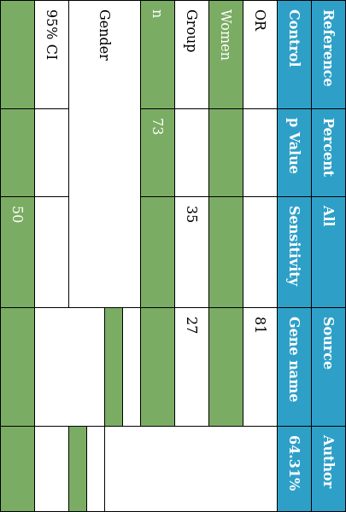

In [ ]:
IPython.display.display(IPython.display.Image(filename=path_to_img))

In [ ]:
IPython.display.display(IPython.display.HTML(html_img))

In [ ]:
res = get_metrics(RotationPaddleRecognizer())
res

100%|██████████| 1000/1000 [02:21<00:00,  7.06it/s]


{'TEDS': 0.6382290310399411, 'TEDS-struct': 0.6982874315214649}

In [ ]:
print(
    f'TEDS: {res['TEDS']:.3f}\n'
    f'TEDS-struct: {res['TEDS-struct']:.3f}'
)

TEDS: 0.638
TEDS-struct: 0.698


In [ ]:
all_result['RotationPaddleRecognizer'] = res

### RotationQwen3VLRecognizer

In [ ]:
class RotationQwen3VLRecognizer(TableRecognizer):
  transform = torchvision.transforms.Compose([
      torchvision.transforms.Grayscale(num_output_channels=1),
      torchvision.transforms.Resize((256, 256)),
      torchvision.transforms.ToTensor(),
  ])

  def __init__(self) -> None:
    super().__init__()
    self.model = RotationModel(4)
    self.model.load_state_dict(
        torch.load(
            path_to_model_weights,
            weights_only=True,
        ),
    )
    self.model.eval()

  def pred(self, path_to_img: pathlib.Path) -> str:
    image = PIL.Image.open(path_to_img)
    image = self.transform(image).unsqueeze(0)
    class_rotation = self.model(image)[0].argmax().item()
    image = PIL.Image.open(path_to_img)
    image = image.rotate(90 * class_rotation, expand=True)
    messages = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": np.array(image),
                },
                {
                    "type": "text",
                    "text": (
                        "Extract the table from this image and output it as valid HTML. "
                        "Use <table>, <thead>, <tbody>, <tr>, <th>, <td> tags. "
                        "Include basic styling: border: 1px solid black; font-size: 10px;. "
                        "Preserve all cells, including rowspan and colspan if present."
                    )
                },
            ],
        }
    ]

    inputs = processor.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt"
    )
    inputs = inputs.to(model.device)

    generated_ids = model.generate(**inputs, max_new_tokens=2048)
    generated_ids_trimmed = [
        out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]
    output_text = processor.batch_decode(
        generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )
    return format_html(output_text[0].strip('```html').strip('```').strip())

In [ ]:
path_to_img = test_images[1].path_to_img
html_img = RotationQwen3VLRecognizer().cache_pred(path_to_img)

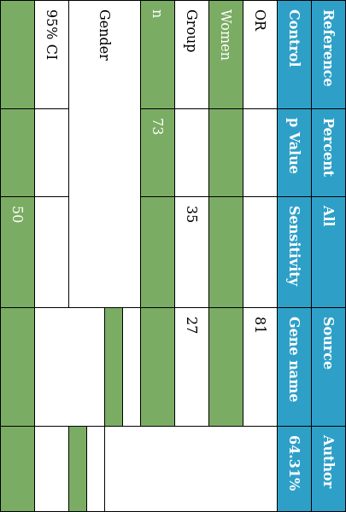

In [ ]:
IPython.display.display(IPython.display.Image(filename=path_to_img))

In [ ]:
IPython.display.display(IPython.display.HTML(html_img))

In [ ]:
res = get_metrics(RotationQwen3VLRecognizer())
res

100%|██████████| 1000/1000 [02:02<00:00,  8.17it/s]


{'TEDS': 0.20824209538741456, 'TEDS-struct': 0.315012526304649}

In [ ]:
print(
    f'TEDS: {res['TEDS']:.3f}\n'
    f'TEDS-struct: {res['TEDS-struct']:.3f}'
)

TEDS: 0.208
TEDS-struct: 0.315


In [ ]:
all_result['RotationQwen3VLRecognizer'] = res

## Comparison of model results

In [54]:
pd.DataFrame(all_result).T

,TEDS,TEDS-struct
PaddleRecognizer,0.605333,0.677823
Qwen3VLRecognizer,0.129730,0.264343
RotationPaddleRecognizer,0.638229,0.698287
RotationQwen3VLRecognizer,0.208242,0.315013


The best model is RotationPaddleRecognizer, as per TEDS, TEDS-struct.